In [1]:
# Import the relevant librarys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits

In [ ]:
def damped_sine(x, a, w, phi, l):

    ''' 
    Purpose
    -------
    This function generates a damped sine wave.

    Parameters
    ----------
    x : array_like
        Position array.

    a : float
        Amplitude of the sine wave.

    w : float
        Angular frequency of the sine wave.

    phi : float
        Phase shift of the sine wave.

    tau : float
        Damping time constant.

    Returns
    -------
    array_like
        Damped sine wave evaluated at time t.

    Author(s)
    ---------
    Julio Morales, November 19th, 2025
    '''

    # Calculate the damped sine wave
    eq = a * np.sin(w * x + phi) * np.exp(x*l)

    return eq

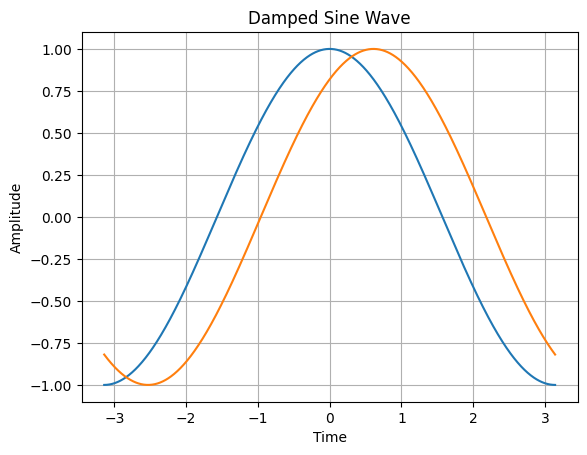

-35.0


In [83]:
# Plot a damped sine wave
x = np.linspace(-np.pi, np.pi, 1000)
a = 1
w = 1
phi1 = 90*np.pi/180
phi2 = 90*np.pi/180 - 35*np.pi/180
c1 = 1
c2 = 3
L = 0#c1 #+ 1j*c2
c3 = 1
y = c3*damped_sine(x, a, w, phi1, L)
y2 = c3*damped_sine(x, a, w, phi2, L)

plt.plot(x, y)
plt.plot(x, y2)
plt.title('Damped Sine Wave')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

print((phi2 - phi1)*180/np.pi)  # in degrees

In [94]:
(np.pi%2.5)*180/np.pi

36.76055121729419

In [3]:
# Load in the data
path = '/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx'
data = fits.getdata(path + '', header = False)

# Extract the phase that you want
phaseA = data['phaseA']

# Take a 1D slice
phaseA_slice = phaseA[50, 50, :]

# Plot the phase slice
xlabel = 'Skip Distance [Mm]'
ylabel = 't [min]'
plt.figure(figsize=(10, 5))
plt.plot(phaseA_slice, label='Phase Slice at (50, 50)')
plt.title('Phase Slice from 3D Data Cube')
plt.ylabel(ylabel)
plt.xlabel(xlabel)
plt.legend()
plt.grid()
plt.show()

# Define the time array
skip_distances = np.arange(0, 125, 6)
initial_guess = [1.0, 0.1, 0.0, 100.0]

# Perform the curve fitting
params, covariance = curve_fit(damped_sine, skip_distances, phaseA_slice, p0=initial_guess)

# Extract the fitted parameters
a_fit, w_fit, phi_fit, tau_fit = params

# Generate the fitted curve
fitted_curve = damped_sine(skip_distances, a_fit, w_fit, phi_fit, tau_fit)

# Plot the original data and the fitted curve
plt.figure(figsize=(10, 5))
plt.plot(skip_distances, phaseA_slice, label='Original Data', color='blue')
plt.plot(skip_distances, fitted_curve, label='Fitted Curve', color='red', linestyle='--')
plt.title('Damped Sine Wave Fit to Phase Slice')
plt.ylabel(ylabel)
plt.xlabel(xlabel)
plt.legend()
plt.grid()
plt.show()

IsADirectoryError: [Errno 21] Is a directory: '/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx'

In [ ]:
# Take power spectrumof the 1D slice
power_spectrum = np.abs(np.fft.fft(phaseA_slice))**2
wavenumber = np.fft.fftfreq(len(phaseA_slice), d=(skip_distances[1] - skip_distances[0]))

# Find the dominant wavenumber
dominant_wavenumber = wavenumber[np.argmax(power_spectrum)]
print(f'Dominant Wavenumber: {dominant_wavenumber} 1/Mm')

plt.figure(figsize=(10, 5))
plt.plot(wavenumber, power_spectrum)
plt.title('Power Spectrum of Phase Slice')
plt.xlabel(r'$k_h$ [1/Mm]')
plt.ylabel('Power')
plt.grid()
plt.show()